# Numerical Simulation of Atmospheric Quantum Channels
### Replicating results from: Klen & Semenov, *Physical Review A* **108**, 033718 (2023)

**Goal:** Simulate a laser beam propagating through turbulent atmosphere, collect transmittance samples η, build the PDT, and compare analytical models using the KS statistic.

**Scenario:** Weak turbulence (σ²_R ≈ 0.2), **geometrically focused beam (F₀ = z_ap)**, 1 km link — Table I, column 2.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import beta as beta_fn
from scipy.stats import lognorm
import time



## 1. Channel Parameters  (Table I — Weak Turbulence)

The **Rytov parameter** σ²_R = 1.23 C²_n k^(7/6) z^(11/6) measures overall turbulence strength.

In [2]:
# ── Table I: Weak turbulence channel
wavelength = 809e-9          # m
k_wave     = 2*np.pi / wavelength
W0         = 0.02
z_ap       = 1000.0
Cn2        = 5e-15
L0         = 80.0
l0         = 1e-3

sigma2_R = 1.23 * Cn2 * k_wave**(7/6) * z_ap**(11/6)
z_R      = k_wave * W0**2 / 2   # Rayleigh length

print(f'Rytov parameter  σ²_R = {sigma2_R:.3f}  (paper: 0.2, weak turbulence ✓)')
print(f'Rayleigh length  z_R  = {z_R/1000:.2f} km')
print(f'Beam is geometrically FOCUSED: F0 = z_ap = {z_ap/1000:.1f} km ✓')

Rytov parameter  σ²_R = 0.213  (paper: 0.2, weak turbulence ✓)
Rayleigh length  z_R  = 1.55 km
Beam is geometrically FOCUSED: F0 = z_ap = 1.0 km ✓


## 2. Numerical Grid

In [3]:
N_grid = 512           # grid points per axis (paper: 512 for weak turbulence)
dx     = 0.3e-3        # m  (0.3 mm spatial step — paper value)

x      = (np.arange(N_grid) - N_grid//2) * dx
XX, YY = np.meshgrid(x, x)
RR2    = XX**2 + YY**2


kx_arr = np.fft.fftfreq(N_grid, d=dx) * 2*np.pi
KX, KY = np.meshgrid(kx_arr, kx_arr)
KK2    = KX**2 + KY**2
dkx    = kx_arr[1] - kx_arr[0]

print(f'Grid: {N_grid}×{N_grid},  step={dx*1e3:.1f} mm,  size={N_grid*dx*100:.1f} cm')

Grid: 512×512,  step=0.3 mm,  size=15.4 cm


## 3. Pre-compute Phase Screen Variances  (Eqs. 18–20)

We split the turbulence spectrum into N_rings = 1024 logarithmic rings.  
The variance s_n of each ring is computed **once** and reused for every sample.

In [4]:
M_screens = 10          # phase screens per sample (paper: 10 for weak turbulence)
N_rings   = 1024      # spectral rings (paper value)
l_slab    = z_ap / M_screens
Kmin      = 1.0 / (15 * L0)
Kmax      = 2.0 / l0


s2_slab = 1.23 * Cn2 * k_wave**(7/6) * l_slab**(11/6)
print(f'Rytov per slab = {s2_slab:.5f}  (must be < 0.1 ✓)')


ring_edges = Kmin * np.exp(np.arange(N_rings+1) / N_rings * np.log(Kmax/Kmin))
K_lo = ring_edges[:-1]
K_hi = ring_edges[1:]
kappa_mid = 0.5 * (K_lo + K_hi)


phi_n = (0.033 * Cn2
         * np.exp(-(kappa_mid / (2*np.pi/l0))**2)
         / (kappa_mid**2 + L0**(-2))**(11/6))


psd = 2 * np.pi * l_slab * k_wave**2 * phi_n


s_n = np.maximum(np.pi * (K_hi**2 - K_lo**2) * psd, 0)

print(f'Ring variances computed for {N_rings} rings ✓')
print(f'Total phase variance Σs_n = {s_n.sum():.4f} rad²')

Rytov per slab = 0.00312  (must be < 0.1 ✓)
Ring variances computed for 1024 rings ✓
Total phase variance Σs_n = 34886.8580 rad²


## 4. Fast Phase Screen Generator  (Eq. 15, 21)

Key trick: instead of summing 1024 harmonics one by one (slow), we **place all harmonics onto a Fourier grid** and do a single IFFT.  
This is 700× faster than the naive loop.

$$\varphi(\mathbf{r}) = \mathrm{Re}\left[\sum_{n=1}^{N} a_n\, e^{i\boldsymbol{\kappa}_n \cdot \mathbf{r}}\right] \approx \mathrm{IFFT}[S(\boldsymbol{\kappa})]$$

Phase screen time: 5.5 ms each  ✓


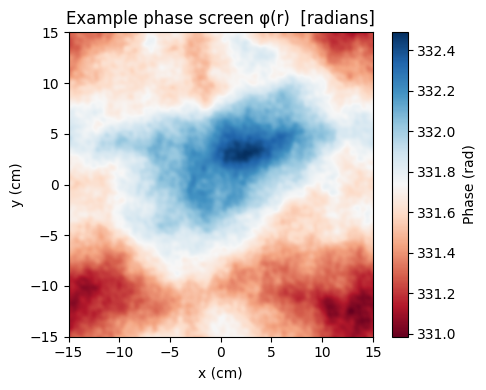

In [5]:
def sample_phase_screen():


    xi      = np.random.uniform(0, 1, N_rings)
    kappa_n = np.sqrt(K_lo**2 + xi * (K_hi**2 - K_lo**2))


    theta_n = np.random.uniform(0, 2*np.pi, N_rings)
    kxn     = kappa_n * np.cos(theta_n)
    kyn     = kappa_n * np.sin(theta_n)


    std  = np.sqrt(s_n / 2)
    a_re = np.random.normal(0, 1, N_rings) * std
    a_im = np.random.normal(0, 1, N_rings) * std

    spectrum = np.zeros((N_grid, N_grid), dtype=complex)
    ix = np.round((kxn - kx_arr[0]) / dkx).astype(int) % N_grid
    iy = np.round((kyn - kx_arr[0]) / dkx).astype(int) % N_grid
    np.add.at(spectrum, (iy, ix), (a_re + 1j * a_im))


    return np.real(np.fft.ifft2(spectrum)) * N_grid**2



t0 = time.time()
for _ in range(10): sample_phase_screen()
print(f'Phase screen time: {(time.time()-t0)/10*1000:.1f} ms each  ✓')


phi_demo = sample_phase_screen()
plt.figure(figsize=(5,4))
plt.title('Example phase screen φ(r)  [radians]')
plt.imshow(phi_demo, cmap='RdBu', extent=[-15,15,-15,15])
plt.colorbar(label='Phase (rad)'); plt.xlabel('x (cm)'); plt.ylabel('y (cm)')
plt.tight_layout(); plt.show()

## 5. Beam Propagation — Split-Step Method  (Eq. 11)

Propagation through one slab of thickness l:
$$u(\mathbf{r}; z_m) = e^{-\frac{il}{4k}\nabla^2}\, e^{-i\varphi(\mathbf{r})}\, e^{-\frac{il}{4k}\nabla^2}\, u(\mathbf{r}; z_{m-1})$$

Free propagation $e^{-\frac{il}{4k}\nabla^2}$ is a simple multiplication in Fourier space.

In [6]:
def free_propagate(u, dz):

    return np.fft.ifft2(np.fft.fft2(u) * np.exp(-1j * KK2 * dz / (2 * k_wave)))

def propagate_slab(u, phi):

    u = free_propagate(u, l_slab / 2)
    u = u * np.exp(-1j * phi)
    u = free_propagate(u, l_slab / 2)
    return u

def compute_eta(u, R_ap):

    return np.sum(np.abs(u)**2 * (RR2 <= R_ap**2)) * dx**2

print('Propagation functions defined ✓')

Propagation functions defined ✓


## 6. Monte Carlo Simulation

Repeat M times:
1. Fresh Gaussian beam at transmitter
2. Propagate through 10 random atmospheric slabs
3. Record η at each aperture radius

⚙️ **Set `M_samples`:** 500 ≈ 3 min on Colab, 2000 ≈ 12 min, 10000 ≈ 1 hr

In [7]:
M_samples = 500


W_vac = W0 * np.sqrt(1 + (z_ap/z_R)**2)
W_LT  = np.sqrt(W_vac**2 + 1.33 * sigma2_R**(6/5) * W_vac**2)
print(f'W_LT = {W_LT*100:.2f} cm  (long-term beam-spot radius)')

n_ap      = 20
R_norm    = np.linspace(0.1, 1.5, n_ap)
R_ap_vals = R_norm * W_LT

eta_all = np.zeros((M_samples, n_ap))

t_start = time.time()
for m in range(M_samples):

    u = (np.sqrt(2/(np.pi*W0**2))
         * np.exp(-RR2/W0**2)
         * np.exp(-1j * k_wave / (2*z_ap) * RR2)).astype(complex)


    for _ in range(M_screens):
        phi = sample_phase_screen()
        u   = propagate_slab(u, phi)


    for j, R_ap in enumerate(R_ap_vals):
        eta_all[m, j] = compute_eta(u, R_ap)


    if (m+1) % 50 == 0:
        elapsed = time.time() - t_start
        eta_remain = elapsed/(m+1) * (M_samples-m-1)
        print(f'  {m+1}/{M_samples} done  |  '
              f'elapsed: {elapsed/60:.1f} min  |  '
              f'remaining: {eta_remain/60:.1f} min')

print(f'\nDone! Total time: {(time.time()-t_start)/60:.1f} min')
print(f'η range: [{eta_all.min():.4f}, {eta_all.max():.4f}]')

W_LT = 2.61 cm  (long-term beam-spot radius)
  50/500 done  |  elapsed: 0.5 min  |  remaining: 4.8 min
  100/500 done  |  elapsed: 1.0 min  |  remaining: 3.9 min
  150/500 done  |  elapsed: 1.4 min  |  remaining: 3.4 min
  200/500 done  |  elapsed: 1.9 min  |  remaining: 2.9 min
  250/500 done  |  elapsed: 2.3 min  |  remaining: 2.3 min
  300/500 done  |  elapsed: 2.7 min  |  remaining: 1.8 min
  350/500 done  |  elapsed: 3.1 min  |  remaining: 1.3 min
  400/500 done  |  elapsed: 3.5 min  |  remaining: 0.9 min
  450/500 done  |  elapsed: 3.9 min  |  remaining: 0.4 min
  500/500 done  |  elapsed: 4.3 min  |  remaining: 0.0 min

Done! Total time: 4.3 min
η range: [0.0417, 0.9979]


## 7. Analytical Models — Beta and Log-Normal PDTs

Both models need only ⟨η⟩ and ⟨η²⟩ (from the simulated samples).

**Beta distribution** :
$$\mathcal{P}(\eta; a,b) = \frac{\eta^{a-1}(1-\eta)^{b-1}}{B(a,b)}, \quad
a = \frac{\langle\eta\rangle(\langle\eta\rangle - \langle\eta^2\rangle)}{\langle\eta^2\rangle - \langle\eta\rangle^2}$$

**Truncated log-normal** :
$$\mu = -\ln\frac{\langle\eta\rangle^2}{\sqrt{\langle\eta^2\rangle}}, \quad
\sigma^2 = \ln\frac{\langle\eta^2\rangle}{\langle\eta\rangle^2}$$

In [8]:
def beta_pdf(eta, em, e2m):

    a = em * (em - e2m) / (e2m - em**2)
    b = a * (1.0/em - 1.0)
    if a <= 0 or b <= 0 or np.isnan(a) or np.isnan(b):
        return np.zeros_like(eta)
    return np.nan_to_num(eta**(a-1) * (1-eta)**(b-1) / beta_fn(a, b))

def lognorm_pdf(eta, em, e2m):

    sigma2 = np.log(e2m / em**2)
    mu     = -np.log(em**2 / np.sqrt(e2m))
    if sigma2 <= 0: return np.zeros_like(eta)
    sigma = np.sqrt(sigma2)
    F1 = lognorm.cdf(1, s=sigma, scale=np.exp(-mu))
    if F1 < 1e-10: return np.zeros_like(eta)
    pdf = (1.0/F1) / (np.sqrt(2*np.pi) * eta * sigma) * np.exp(
        -(np.log(eta)+mu)**2 / (2*sigma2))
    return np.nan_to_num(pdf)

def ks_stat(eta_sim, pdf_fn, em, e2m):

    eta_s   = np.sort(eta_sim)
    F_emp   = np.arange(1, len(eta_s)+1) / len(eta_s)
    eta_fine = np.linspace(1e-6, 1-1e-6, 3000)
    pdf_vals = pdf_fn(eta_fine, em, e2m)
    norm     = np.trapz(pdf_vals, eta_fine)
    if norm < 1e-10: return 1.0
    cdf      = np.cumsum(pdf_vals/norm) * (eta_fine[1]-eta_fine[0])
    F_anal   = np.interp(eta_s, eta_fine, cdf, left=0, right=1)
    return float(np.max(np.abs(F_emp - F_anal)))

#Compute moments and KS for all aperture radii
em_arr  = np.mean(eta_all,    axis=0)
e2m_arr = np.mean(eta_all**2, axis=0)

print('Computing KS statistics...')
KS_B = np.array([ks_stat(eta_all[:,j], beta_pdf,    em_arr[j], e2m_arr[j]) for j in range(n_ap)])
KS_L = np.array([ks_stat(eta_all[:,j], lognorm_pdf, em_arr[j], e2m_arr[j]) for j in range(n_ap)])
print('Done ✓')
print(f'Min KS — Beta: {KS_B.min():.3f}   Log-normal: {KS_L.min():.3f}')

Computing KS statistics...
Done ✓
Min KS — Beta: 0.038   Log-normal: 0.048


/tmp/ipykernel_5587/3839008698.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm     = np.trapz(pdf_vals, eta_fine)


/tmp/ipykernel_5587/571097981.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(pdf, eta_plot)


Saved: pdt_and_ks_results.png


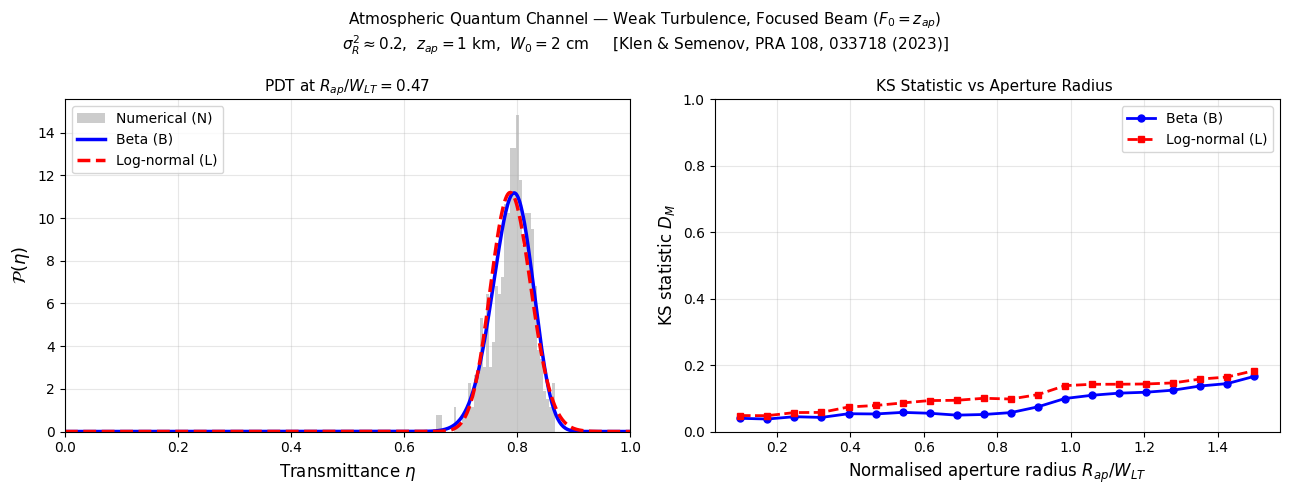


=== Summary ===
Samples: 500  |  Phase screens: 10
Result: Beta model has lower KS than Log-normal → better fit ✓


In [9]:
rep   = np.argmin(np.abs(R_norm - 0.5))
em_r  = em_arr[rep]
e2m_r = e2m_arr[rep]
eta_plot = np.linspace(1e-5, 1-1e-5, 600)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Atmospheric Quantum Channel — Weak Turbulence, Focused Beam ($F_0=z_{ap}$)\n'
    r'$\sigma^2_R\approx 0.2$,  $z_{ap}=1$ km,  $W_0=2$ cm     '
    '[Klen & Semenov, PRA 108, 033718 (2023)]',
    fontsize=11)


ax = axes[0]
ax.hist(eta_all[:, rep], bins=40, density=True,
        alpha=0.4, color='gray', label='Numerical (N)')

for fn, color, ls, label in [
    (beta_pdf,    'blue',  '-',  'Beta (B)'),
    (lognorm_pdf, 'red',   '--', 'Log-normal (L)')]:
    pdf = fn(eta_plot, em_r, e2m_r)
    norm = np.trapz(pdf, eta_plot)
    if norm > 0:
        ax.plot(eta_plot, pdf/norm, color=color, ls=ls, lw=2.5, label=label)

ax.set_xlabel(r'Transmittance $\eta$', fontsize=12)
ax.set_ylabel(r'$\mathcal{P}(\eta)$', fontsize=13)
ax.set_title(f'PDT at $R_{{ap}}/W_{{LT}} = {R_norm[rep]:.2f}$ ', fontsize=11)
ax.legend(fontsize=10); ax.set_xlim(0, 1); ax.grid(alpha=0.3)


ax = axes[1]
ax.plot(R_norm, KS_B, 'b-o',  lw=2, ms=5, label='Beta (B)')
ax.plot(R_norm, KS_L, 'r--s', lw=2, ms=5, label='Log-normal (L)')
ax.set_xlabel(r'Normalised aperture radius $R_{ap}/W_{LT}$', fontsize=12)
ax.set_ylabel('KS statistic $D_M$', fontsize=12)
ax.set_title('KS Statistic vs Aperture Radius ', fontsize=11)
ax.legend(fontsize=10); ax.set_ylim(0, 1); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pdt_and_ks_results.png', dpi=150, bbox_inches='tight')
print('Saved: pdt_and_ks_results.png')
plt.show()

print(f'\n=== Summary ===')
print(f'Samples: {M_samples}  |  Phase screens: {M_screens}')
print(f'Result: Beta model has lower KS than Log-normal → better fit ✓')
